In [3]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import scipy
import pandas as p
import sys
module_path = os.path.abspath(os.path.join(r'D:\PhD\PythonScripts'))
if module_path not in sys.path:
    sys.path.append(module_path)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.ticker as ticker
import importlib
import os
from glob import glob
from IPython.display import display, HTML



import elchem_handy_V4_1 as pyfai
import copy
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from scipy.signal import savgol_filter

from itertools import zip_longest

# import ipywidgets as widgets
# from ipywidgets import HBox, VBox
# from IPython.display import display

import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (8, 8),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large',
         'figure.autolayout' : True}
pylab.rcParams.update(params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set your parameters

In [4]:
path_OUT=r'C:\Latex_HDD\Clanek_AEM\RDE_Kosto\export'

if not os.path.exists(path_OUT):
    os.makedirs(path_OUT)
    
# area for normalization

area=0.19634

## Define and load your samples

In [5]:
sample1=r'C:\Latex_HDD\Clanek_AEM\RDE_Kosto\40_Ir on GC_HClO4 0_1M'
sample2=r'C:\Latex_HDD\Clanek_AEM\RDE_Kosto\41_Ir50Ru50 on Au_HClO4 0_1M'
#sample3=r'D:\PhD\Prague OPJAK\experiments\AEM WE\RDE data analysis\Kosto\44-Ir25Ru75 on Au_HClO4 0_1M'
#sample4=r'D:\PhD\Prague OPJAK\experiments\AEM WE\RDE data analysis\Kosto\45_Ir75Ru25 on Au_HClO4 0_1M'
#sample5=r'D:\PhD\Prague OPJAK\experiments\AEM WE\RDE data analysis\Kosto\48_IrOx on GC_HClO4 0_1M'


data1,flist1,fname1= pyfai.loadFilesMPT(folder=sample1,wild ='*')
data2,flist2,fname2= pyfai.loadFilesMPT(folder=sample2,wild ='*')
#data3,flist3,fname3= pyfai.loadFilesMPT(folder=sample3,wild ='*')
#data4,flist4,fname4= pyfai.loadFilesMPT(folder=sample4,wild ='*')
#data5,flist5,fname5= pyfai.loadFilesMPT(folder=sample5,wild ='*')
#data6,flist6,fname6= pyfai.loadFilesMPT(folder=sample6,wild ='*')

# pick the datasets you want to plot
data_samples = [data1,data2]
fname_samples=[fname1,fname2]

for i,item in enumerate(fname_samples):
    print('Sample nr: ', i+1)
    print(item)
    print(pyfai.genproc(item))

Sample nr:  1
['01_Procedure_Performance_03_PEIS_C01.mpt', '01_Procedure_Performance_04_CV_C01.mpt', '01_Procedure_Performance_05_LSV_C01.mpt', '01_Procedure_Performance_06_PEIS_C01.mpt', '01_Procedure_Performance_08_CA_C01.mpt']
['01: P', '01: P', '01: P', '01: P', '01: P']
Sample nr:  2
['01_Procedure_Performance_03_PEIS_C01.mpt', '01_Procedure_Performance_04_CV_C01.mpt', '01_Procedure_Performance_05_LSV_C01.mpt', '01_Procedure_Performance_06_PEIS_C01.mpt', '01_Procedure_Performance_08_CA_C01.mpt']
['01: P', '01: P', '01: P', '01: P', '01: P']


## EIS Voltages available


In [6]:
# put for i the number of the PEIS file
i=4
RHE=0
rounded_values = np.round(data1[i-1][:,6], 3)
unique_values = np.unique(rounded_values+RHE)
print(unique_values)

[1.3  1.35 1.4  1.45 1.5  1.55 1.6 ]


## Select what you want to plot for each sample corrected or not

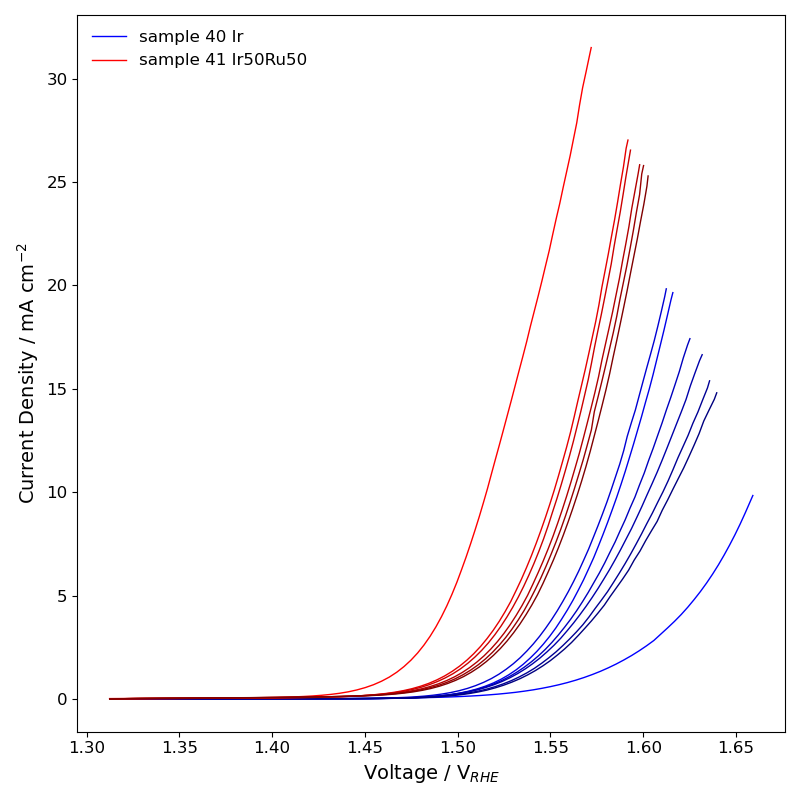

[{'sample_label': 'sample 40 Ir', 'results': [{'cycle': 1.0, 'slope': 71.73157423798952, 'intercept': -4.706508846593569, 'r_squared': 0.9998545086892697, 'exchange_current_density': 1.9655819412006615e-05, 'overpotential_10_mA_cm2': nan}, {'cycle': 2.0, 'slope': 39.011170426479296, 'intercept': -7.492978466349127, 'r_squared': 0.9998860632059821, 'exchange_current_density': 3.213819885725289e-08, 'overpotential_10_mA_cm2': 362.5475687972406}, {'cycle': 3.0, 'slope': 41.42237174314408, 'intercept': -6.936681590841622, 'r_squared': 0.9998256135694663, 'exchange_current_density': 1.1569601730762242e-07, 'overpotential_10_mA_cm2': 357.22208367870235}, {'cycle': 4.0, 'slope': 40.75554733839906, 'intercept': -7.210315240837794, 'r_squared': 0.9999640093954154, 'exchange_current_density': 6.16147597152434e-08, 'overpotential_10_mA_cm2': 372.9355087498171}, {'cycle': 5.0, 'slope': 40.67527197356017, 'intercept': -7.241632792606265, 'r_squared': 0.9996654381064989, 'exchange_current_density': 

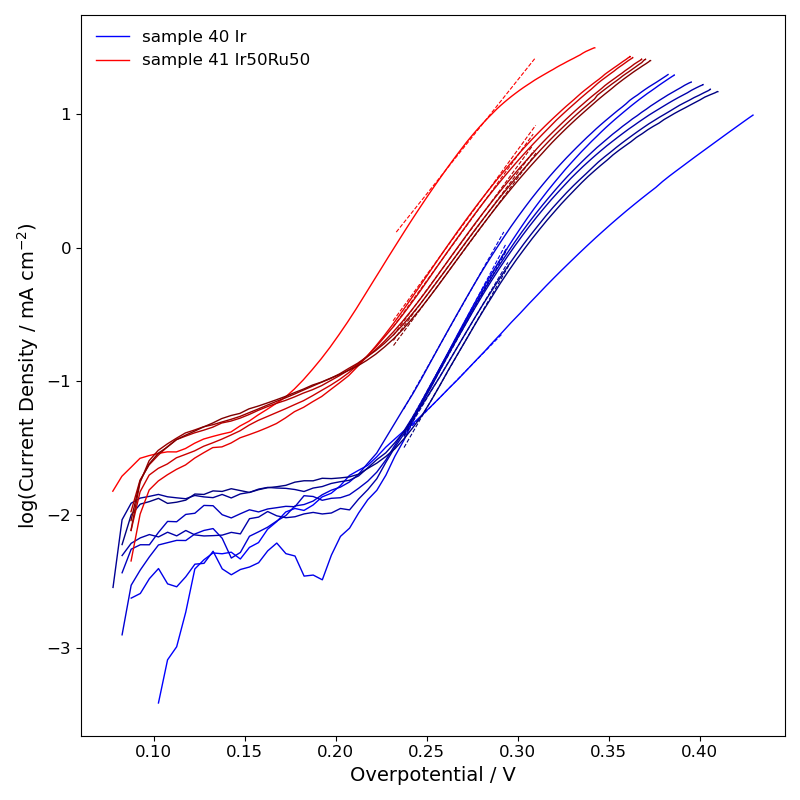

Tafel regression results saved to: C:\Latex_HDD\Clanek_AEM\RDE_Kosto\export\Ir-Ru_Ohm_Tafel_fit.csv


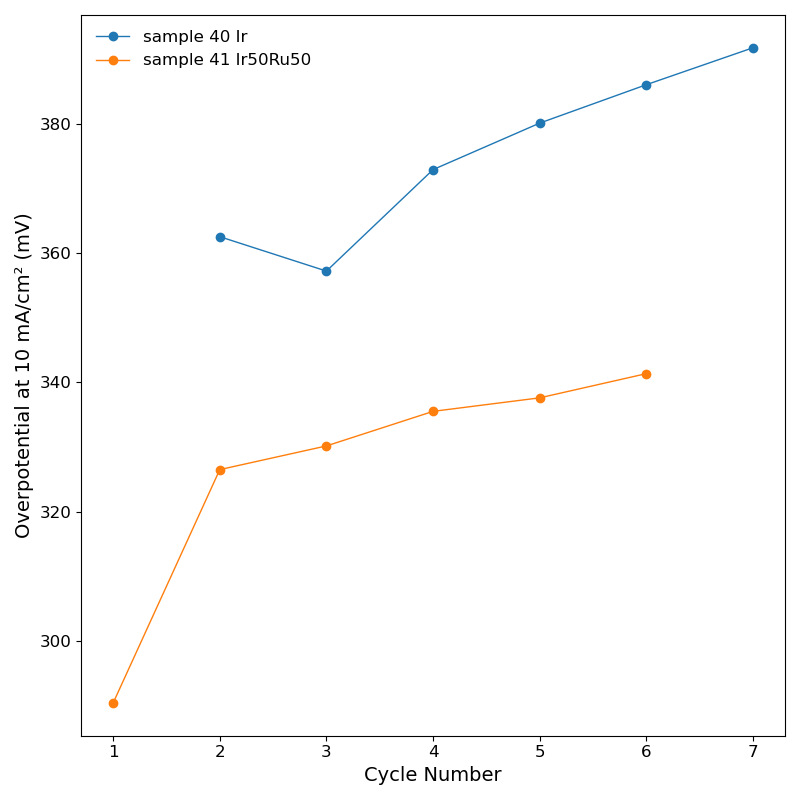

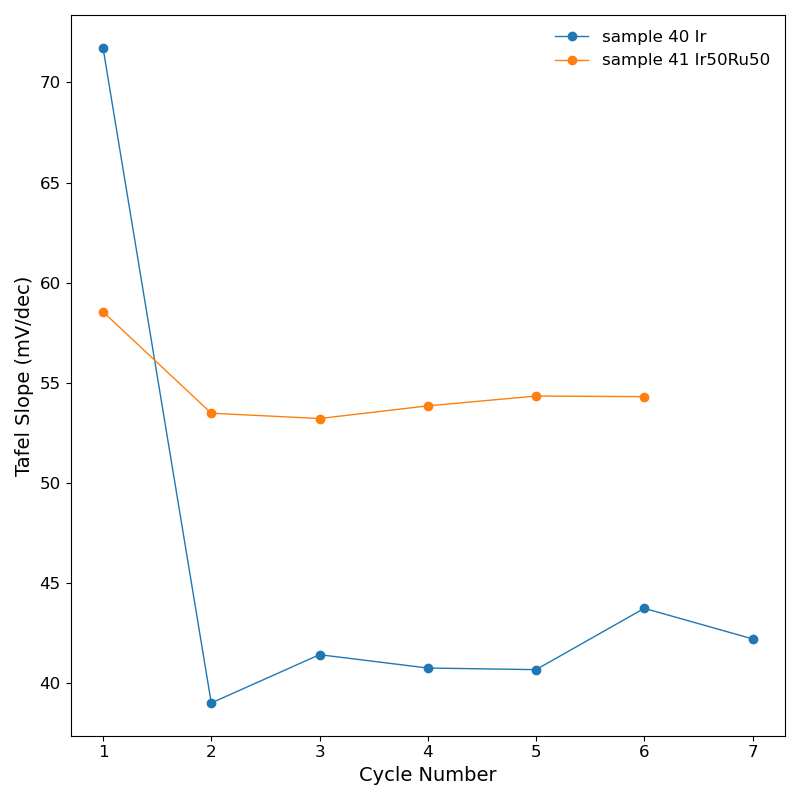

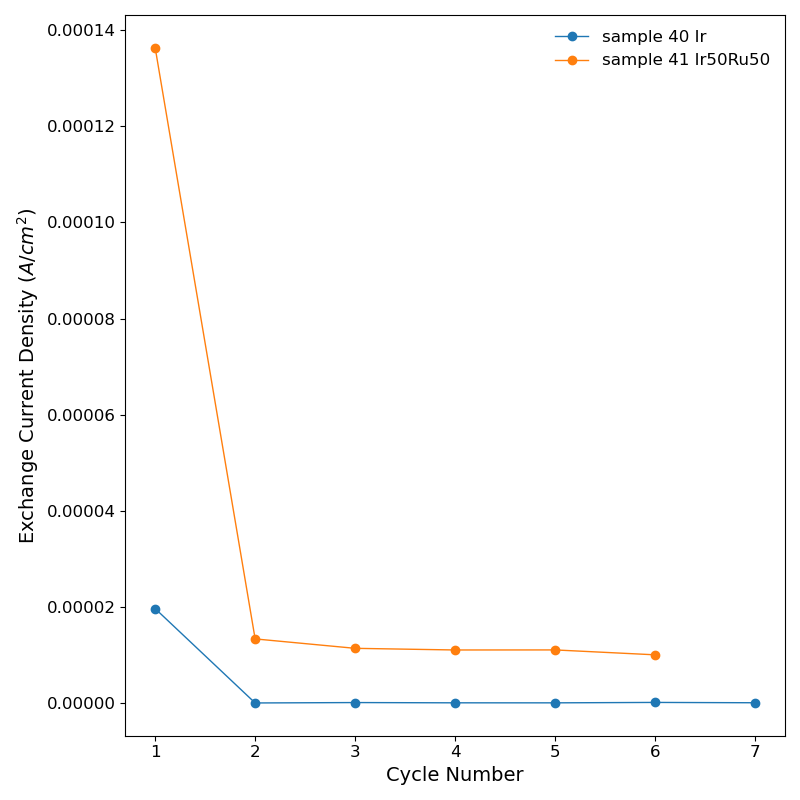

In [38]:
%matplotlib widget
name='Ir-Ru_Ohm'
## common parameters.

base_params = {
    'procedure': 'LSV',  # LSV, CV, PEIS, CA
#    'EIS_E': 'all',     #  [1.349,1.449], 'all'
#    'fR': 'all',     #[1E4, 1], 'all'
    'Correct_by_R' : 1,         ### correct ratio of resistance, 1 = full correction
#    'Correct_to_R' : 5,          ### corrects to the specific value in ohms
    'Tafel' : True,
    'E_rev' : 1.23,
    'U_shift_to_RHE': 0, ## Shift to RHE electrode in V
    'overpotential' : 10
}

## free parameters

user_params_list = [
    {'label': 'sample 40 Ir', 'color': 'blue',
     'cycle_range': [1,2,3,4,5,6,7], 'proc_nr' : 'all', 'seq': 'all','repetition':'all', 'S': area, 
     'R_ohm': [21.2, 21.8, 22.5, 21.9, 20.9, 21.3, 20.8], 'Tafel_ranges' : [[0.25,0.28]]},
    {'label': 'sample 41 Ir50Ru50', 'color': 'red',
     'cycle_range': [1, 2, 3, 4, 5, 6], 'proc_nr' : 'all', 'seq': 'all','repetition':'all', 'S': area, 
     'R_ohm': [20.7, 20.4, 20.5, 20.1, 19.7, 19.6, 19.6], 'Tafel_ranges' : [[0.25,0.29]]},
#    {'label': 'sample 44 Ir25Ru75', 'color': 'magenta',
#     'cycle_range': [1, 2, 3, 4,5,6,7], 'proc_nr' : 'all', 'seq': 'all','repetition':'all', 'S': area, 
#     'R_ohm': [20.9,21.0,20.7,20.8,20.7,20.7,20.6], 'Tafel_ranges' : [[0.25,0.28], [0.25,0.28]]},
#    {'label': 'sample 45 Ir75Ru25', 'color': 'green',
#     'cycle_range': [1, 2, 3, 4,5,6,7], 'proc_nr' : 'all', 'seq': 'all','repetition':'all', 'S': area, 
#     'R_ohm': [21.2,20.7,20.3,20.0, 19.8,19.9,19.8], 'Tafel_ranges' : [[0.25,0.28], [0.27,0.28]]},
#    {'label': 'sample 48 IrOx', 'color': 'black',
#     'cycle_range': [1,2,3,4,5,6,7], 'proc_nr' : 'all', 'seq': 'all','repetition':'all', 'S': area, 
#     'R_ohm': [21.1,22.0,23.5,24.4,19.3,19.2,19.1], 'Tafel_ranges' : [[0.25,0.28]]}
]

# user_params_list = [
#     {'label': 'sample 34 NiFe', 'color': 'blue',
#      'cycle_range': 'all', 'proc_nr' : 'all', 'seq': [6] (0,7), 'S': area}
# ]


plot_params = {
    'title_fontsize': 16,
    'axis_label_fontsize': 14,
    'legend_fontsize': 12,
    'tick_fontsize': 12,
#    'x_range': [0, 500],
#    'y_range': [0, 500],
#    'x_ticks': np.linspace(0, 5, 6),
#    'y_ticks': np.linspace(0, 2, 5),
    'min_size' : 1, 
    'linewidth' : 1,
    'front_gap' : 5, ## removes x data points from the beginning. For loope, the length of the loop must be added: 361
    'back_gap' :-1, ## removes x data points from the end
}
####################################################################################################################################


selectProc_params_list = [
    {
        k: v
        for k, v in {
            **base_params,
            **user_params,
            'front_gap': plot_params.get('front_gap', 0),
            'back_gap': plot_params.get('back_gap', 0),
        }.items()
        if k not in ['label', 'color', 'S', 'R_ohm', 'Correct_to_R', 'Correct_by_R', 'Tafel', 'E_rev', 'Tafel_ranges', 'front_gap', 'back_gap', 'overpotential']
    }
    for user_params in user_params_list
]
processed_data = []
labels = []
colors = []
areas=[]

for data, fname, params, user_params in zip(data_samples, fname_samples, selectProc_params_list, user_params_list):
    data_processed, fname_processed, loops = pyfai.selectProcRDE(data, fname, **params)
    processed_data.append(data_processed)
    labels.append(user_params['label'])
    colors.append(user_params['color'])
    areas.append(user_params['S'])
#Correct the ohmic resistance for LSV, CV
corrected_data = pyfai.correct_R(processed_data, user_params_list, base_params)
# Call the plotData function with the processed datasets, labels, and colors
pyfai.plotDataRDE(corrected_data, labels, colors, areas, base_params, plot_params, user_params_list, folder=path_OUT+'\\'+name, gradient='Y')
if base_params['Tafel'] and (base_params['procedure'] == 'LSV' or base_params['procedure'] == 'CV'):
    ## Do the transformation to the Tafel plot   
    tafel_data = pyfai.tafel_transform(corrected_data, base_params, areas=areas)
    tafel_regression_results = pyfai.calculate_tafel_slopes(tafel_data,corrected_data, user_params_list, base_params)
    print(tafel_regression_results)
    pyfai.plotDataRDE(tafel_data, labels, colors, areas,base_params, plot_params, user_params_list, folder=path_OUT+'\\'+name+'Tafel', gradient='Y', tafel_regression_results=tafel_regression_results)
    output_file = f"{path_OUT}\\{name}_Tafel_fit.csv"
    pyfai.save_tafel_results_to_csv(tafel_regression_results, output_file,base_params)
    pyfai.plot_tafel_results(tafel_regression_results, path_OUT + '\\' + name+'_Tafel_evolution', plot_params, base_params)

## Separate option, if you want to only work with the filtered data

In [6]:
## The corresponding index in the processed_data corresponds to the labels
# processed_data[0][0] = first curve from sample 1
print(labels)

['sample 34 NiFe', 'sample 34 NiFe sec']


IndexError: list index out of range

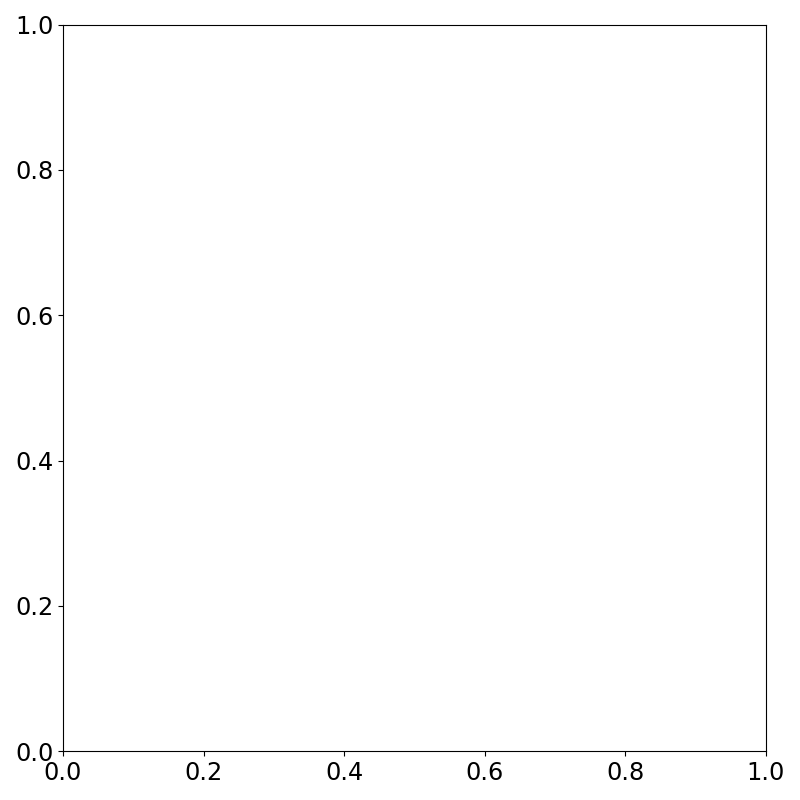

In [55]:
name1='day1_test_SV'

fig = plt.figure()
ax = fig.add_subplot()

#number of sample
i=5

ax.plot(processed_data[i][0][:, 6] / (area), processed_data[i][0][:, 7], label=labels[0] + 'Day 1', color='red')

ax.set_ylabel('Cell Voltage / V')
ax.set_xlabel('Current Density / A cm$^{-2}$')

plt.savefig(path_OUT+'\\'+name+'.png', transparent=True,bbox_inches="tight")
plt.tight_layout()
plt.show()